# Azimuthal integration of GIWAXS frames

Turn raw detector images into 1D intensity vs *q* (full-azimuthal radial integration) for downstream peak fitting and phase identification.

This notebook covers:

1. Integrating a single frame and plotting I(q).
2. Batch-integrating an _in situ_ stack of frames with option to normalise to given _q_.
3. Plotting the _in situ_ integrations as a colour scale. 
4. Plotting the _in situ_ heatmap (q vs frame index) (AKA 'waterfall plot').
5. Saving the batch result as a CSV that later notebooks consume.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, ListedColormap

from giwaxs_analysis import calibration, io, integration

## 1. Load the calibration

Same as [`01_check_calibration.ipynb`](01_check_calibration.ipynb) — point at your PONI + mask and pack them into a `Calibration` object.

In [5]:
PONI_PATH = '../data/calibrant_AgBh.poni'
MASK_PATH = '../data/mask.edf'

calib = calibration.load_calibration(PONI_PATH, MASK_PATH)
print(calibration.summarise(calib))

Pilatus2M  dist=275.7 mm  beam=(209.9, 35.8) mm  λ=1.2398 Å  E=10.000 keV  masked=8.0%


## 2. Azimuthally integrate a single frame

Pick one frame from the _in situ_ series, integrate over χ at each q, and plot I(q). 

**NB.** Default log y-axis so weaker peaks are visible alongside the bright primary reflections. To plot in a linear scale, comment out the line `ax.set_yscale('log')`.

Two user inputs:

- **`CHI_RANGE`** — azimuthal wedge in degrees (between –180 and 180). `None` = full circle. Convention (depends on detector orientation):
  - around `chi ≈ ±90°` — out-of-plane direction (e.g. `(-100, -80)`).
  - around `chi ≈ 0°` or `180°` — in-plane direction (e.g. `(-10, 10)`).
  - this varies depending on beamline so check for features you expect to see in specific directions.
- **`Q_RANGE`** — restrict the radial range to a region of interest in Å⁻¹. `None` = whatever range the geometry covers.

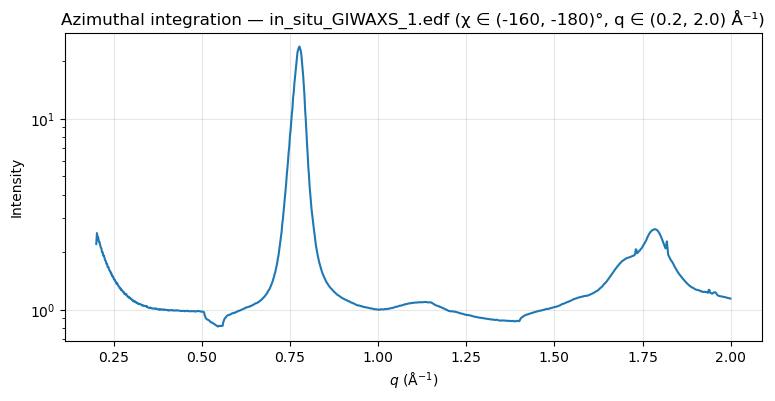

In [6]:
FRAME_PATH = '../data/insitu/in_situ_GIWAXS_1.edf'

# Both ranges default to None — set them to a tuple to restrict.
CHI_RANGE = -160, -180       # e.g. (-100, -80) for out-of-plane
Q_RANGE = 0.2, 2.0      # e.g. (0.2, 2.0)  for a peak of interest

# Optional: normalise to intensity at a specific q (Å⁻¹). Set to None to skip.
NORM_Q = 1          # e.g. 1.0

frame = io.load_frame(FRAME_PATH)
q, I = integration.azimuthal_integrate(frame, calib, chi_range=CHI_RANGE, q_range=Q_RANGE)

if NORM_Q is not None:
    I = I / I[np.argmin(np.abs(q - NORM_Q))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(q, I)
ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Intensity' if NORM_Q is not None else 'Intensity (counts)')
ax.set_yscale('log')   # ← comment out for linear scale
ax.set_title(
    f'Azimuthal integration — {FRAME_PATH.rsplit("/", 1)[-1]}'
    f' (χ ∈ {CHI_RANGE}°, q ∈ {Q_RANGE} Å⁻¹)'
)
ax.grid(True, alpha=0.3)
plt.show()

## 3. Batch-integrate _in situ_ series from a given directory

`io.list_frames` + `io.load_stack` gather every frame in `data/insitu/` into a single 3D array; `batch_integrate` runs `azimuthal_integrate` over each frame and stacks the results into shape `(N_frames, N_q_bins)`.

By default this re-uses the `CHI_RANGE` and `Q_RANGE` you set in step 2 — uncomment the lines below to override them just for the batch (e.g. zoom into a specific peak for the heatmap).

In [7]:
INSITU_DIR = '../data/insitu/'

# Re-uses CHI_RANGE and Q_RANGE from step 2. Uncomment + edit to override:
# CHI_RANGE = (-180, 180)
# Q_RANGE = (0.2, 2.0)

# Optional: normalise every frame to intensity at a specific q (Å⁻¹). Set to None to skip.
NORM_Q = 1          # e.g. 1.0

paths = io.list_frames(INSITU_DIR)
print(f'Found {len(paths)} frames')

stack = io.load_stack(paths)
print(f'Stack shape: {stack.shape}')

q, I_2d = integration.batch_integrate(
    stack, calib, chi_range=CHI_RANGE, q_range=Q_RANGE,
)

if NORM_Q is not None:
    I_2d = I_2d / I_2d[:, np.argmin(np.abs(q - NORM_Q))][:, None]

print(f'q shape: {q.shape}, I_2d shape: {I_2d.shape}')

Found 5 frames
Stack shape: (5, 1679, 1475)
q shape: (1000,), I_2d shape: (5, 1000)


## 4. Overlay every integration with a colour gradient

The same data as the heatmap but as overlaid line plots, with each frame coloured from light blue (first in the series) to dark blue (last). Useful for spotting peak shifts / sharpening / new peaks emerging.

For larger series (~20+ frames) the lines start to overlap badly — the heatmap below is the better view there.

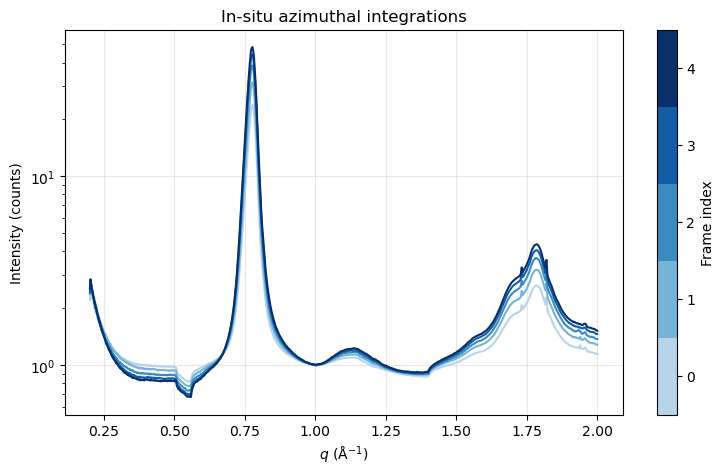

In [8]:
n = len(I_2d)
cmap = plt.get_cmap('Blues')
# Skip the very light end (0.0–0.3) since pale colours vanish on a white background.
colors = cmap(np.linspace(0.3, 1.0, n))

fig, ax = plt.subplots(figsize=(9, 5))
for intensities, color in zip(I_2d, colors):
    ax.plot(q, intensities, color=color)

ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Intensity (counts)')
ax.set_yscale('log')
ax.set_title('In-situ azimuthal integrations')
ax.grid(True, alpha=0.3)

# Discrete colourbar matching the line colours exactly.
sm = plt.cm.ScalarMappable(
    cmap=ListedColormap(colors),
    norm=plt.Normalize(vmin=-0.5, vmax=n - 0.5),
)
plt.colorbar(sm, ax=ax, ticks=range(n), label='Frame index')

plt.show()

## 5. _In situ_ heatmap

A quick look at the _in situ_ series. For a thickness scan, you'd expect peak *positions* to stay constant while intensities scale roughly with film thickness. For a temperature or anneal scan, you'd expect peaks to shift / sharpen / split.

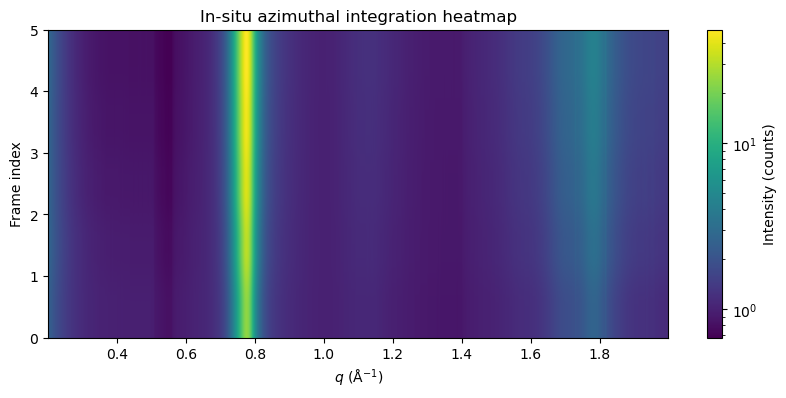

In [9]:
# Intensity range for the colour scale. Set to None to use the data's own min/max.
# Tighten VMIN to suppress noise; tighten VMAX to bring out weaker
# peaks (saturates the brightest pixels). LogNorm requires VMIN > 0.
VMIN = None  # e.g. 10
VMAX = None  # e.g. 5000

LOG_SCALE = True   # ← False for linear colour scale

# Clip non-positive values for LogNorm.
I_plot = np.where(I_2d > 0, I_2d, np.nan)

# Fall back to data range if either is None.
vmin_eff = VMIN if VMIN is not None else np.nanmin(I_plot)
vmax_eff = VMAX if VMAX is not None else np.nanmax(I_plot)

norm = LogNorm(vmin=vmin_eff, vmax=vmax_eff) if LOG_SCALE else Normalize(vmin=vmin_eff, vmax=vmax_eff)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    I_plot,
    aspect='auto',
    origin='lower',
    extent=(q.min(), q.max(), 0, len(I_2d)),
    cmap='viridis',
    norm=norm,
)
ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Frame index')
ax.set_title('In-situ azimuthal integration heatmap')
plt.colorbar(im, ax=ax, label='Intensity (counts)')
plt.show()

## 5. Save as CSV for peak fitting

Write a CSV with column 0 = q and remaining columns = intensities, one per frame. This is the format [`06_peak_fitting_scherrer.ipynb`](06_peak_fitting_scherrer.ipynb) consumes.

**Note**: we save with no metadata rows below the header, so when you load it back use `io.load_integrations_csv(..., skip_data_rows=0)`.

In [10]:
OUTPUT_PATH = '../data/example_integrations.csv'

labels = [p.stem for p in paths]
df = pd.DataFrame({'q': q})
for label, intensities in zip(labels, I_2d):
    df[label] = intensities

df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df)} rows × {len(df.columns)} columns to {OUTPUT_PATH}')
df.head()

Saved 1000 rows × 6 columns to ../data/example_integrations.csv


,q,in_situ_GIWAXS_1,in_situ_GIWAXS_2,in_situ_GIWAXS_3,in_situ_GIWAXS_4,in_situ_GIWAXS_5
0,0.2009,2.203831,2.416406,2.387794,2.430156,2.530672
1,0.2027,2.513946,2.753654,2.704736,2.741556,2.842643
2,0.2045,2.403764,2.624615,2.571680,2.608783,2.698473
3,0.2063,2.393161,2.606034,2.555820,2.583362,2.664818
4,0.2081,2.266163,2.455156,2.413413,2.432644,2.506371
